# EDA — MAVE Laptops NER Dataset

**Dataset:** MAVE Laptops — Electronics subcategory (Amazon Review 2018)  
**Task:** Named Entity Recognition (NER) — sequence labelling  
**Entity types:** `BRAND`, `SCREEN_SIZE`, `PROCESSOR`, `RESOLUTION`, `BATTERY`  
**Format:** BIO tagging scheme  
**Sources:**  
- Li Yang et al., *MAVE: A Product Dataset for Multi-source Attribute Value Extraction*, WSDM 2022
- Jianmo Ni et al., *Justifying Recommendations using Distantly-Labeled Reviews*, EMNLP 2019

## 0) Imports & Setup

In [ ]:
# Install dependencies
!pip install seqeval spacy wordcloud gensim pyLDAvis -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
import random
import re
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot style
sns.set_style('whitegrid')
COLORS = ['#56B4E9', '#E69F00', '#009E73', '#CC79A7', '#0072B2', '#D55E00']
ENTITY_TYPES = ['BRAND', 'SCREEN_SIZE', 'PROCESSOR', 'RESOLUTION', 'BATTERY']

print('Setup complete.')

Setup complete.


## 1) Data Loading

The MAVE Laptops dataset is stored in JSONL format (JSON Lines), where each line is an independent JSON object representing one product sequence. Each record contains a unique product identifier (`id`), a `tokens` list of pre-tokenized strings, and a parallel `labels` list following the BIO tagging scheme.  

The dataset is pre-split into three partitions with an approximately 80/10/10 ratio.

In [4]:
def load_jsonl(path):
    data = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_data = load_jsonl('laptops_train.jsonl')
val_data   = load_jsonl('laptops_val.jsonl')
test_data  = load_jsonl('laptops_test.jsonl')

print(f'Train: {len(train_data):,}')
print(f'Val:   {len(val_data):,}')
print(f'Test:  {len(test_data):,}')
print(f'Total: {len(train_data)+len(val_data)+len(test_data):,}')
print()
print('Sample record:')
print(json.dumps(train_data[0], indent=2))

Train: 7,479
Val:   935
Test:  935
Total: 9,349

Sample record:
{
  "id": "B008FCF5WS",
  "category": "Laptops",
  "tokens": [
    "Lenovo",
    "ThinkPad",
    "32605VU",
    "15.6-Inch",
    "Laptop"
  ],
  "labels": [
    "O",
    "O",
    "O",
    "B-SCREEN_SIZE",
    "O"
  ]
}


The dataset contains 9,349 sequences in total: 7,479 for training, 935 for validation, and 935 for test. The sample record illustrates the BIO structure: each token is aligned with exactly one label, where `B-` marks the beginning of an entity span and `I-` marks its continuation. Tokens outside any entity are tagged `O`. Note that in this example only `15.6-Inch` is annotated, as `B-SCREEN_SIZE` — a pattern representative of the dataset's short, attribute-rich product titles.

## 2) Data Quality Check

Before any analysis or modelling, a set of structural checks is performed to verify dataset integrity. These include: alignment between tokens and labels, duplicate product IDs, split contamination, empty sequences, BIO consistency, and the presence of HTML artifacts from web scraping.

In [5]:
# Token-label alignment
mismatches = [r['id'] for r in train_data if len(r['tokens']) != len(r['labels'])]
print(f'Token-label mismatches:  {len(mismatches)}')

# Duplicate IDs
train_ids = [r['id'] for r in train_data]
val_ids   = [r['id'] for r in val_data]
test_ids  = [r['id'] for r in test_data]
print(f'Duplicate train IDs:     {len(train_ids) - len(set(train_ids))}')
print(f'Train/test overlap:      {len(set(train_ids) & set(test_ids))}')
print(f'Train/val overlap:       {len(set(train_ids) & set(val_ids))}')

# Empty sequences
empty = sum(1 for r in train_data if not r['tokens'])
print(f'Empty sequences (train): {empty}')

# BIO consistency check
bio_errors = 0
for r in train_data:
    for i, lbl in enumerate(r['labels']):
        if lbl.startswith('I-'):
            if i == 0 or (r['labels'][i-1] not in (f'B-{lbl[2:]}', f'I-{lbl[2:]}')):
                bio_errors += 1
print(f'BIO consistency errors:  {bio_errors}')

# HTML artifacts check
html_count = sum(1 for r in train_data for t in r['tokens'] if '&amp;' in t or '&lt;' in t or '&#' in t)
print(f'HTML artifact tokens:    {html_count}')

Token-label mismatches:  0
Duplicate train IDs:     0
Train/test overlap:      0
Train/val overlap:       0
Empty sequences (train): 0
BIO consistency errors:  78
HTML artifact tokens:    0


All critical checks pass: there are no token-label mismatches, duplicate IDs, split overlaps, or empty sequences. However, 78 BIO consistency errors are detected — cases where an `I-` tag follows either `O` or a `B-`/`I-` tag of a different entity class, which is a structural violation of the BIO scheme. These errors reflect annotation noise in the original dataset and will be addressed in the label cleaning pipeline (Notebook 02).

## 3) Sequence Length Distribution

Sequence length is a key property for both model design and training efficiency. In token classification tasks, very short sequences may lack enough context for the model to resolve ambiguous entity boundaries, while very long sequences increase memory usage and may require truncation. Understanding the length distribution across all three splits also helps verify that the dataset partitioning is consistent.

=== Sequence Length Stats (train) ===
  Min:    2
  Max:    75
  Mean:   17.7
  Median: 18.0
  Std:    9.2
  > 50 tokens: 26 (0.3%)


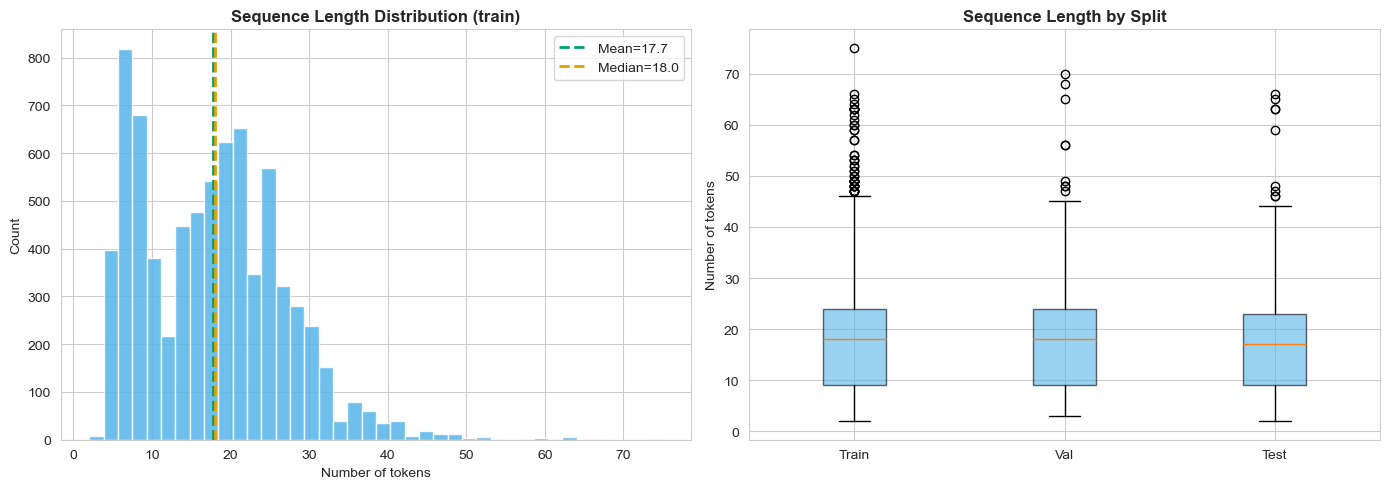

In [6]:
train_lens = [len(r['tokens']) for r in train_data]
val_lens   = [len(r['tokens']) for r in val_data]
test_lens  = [len(r['tokens']) for r in test_data]

print('=== Sequence Length Stats (train) ===')
print(f'  Min:    {min(train_lens)}')
print(f'  Max:    {max(train_lens)}')
print(f'  Mean:   {np.mean(train_lens):.1f}')
print(f'  Median: {np.median(train_lens):.1f}')
print(f'  Std:    {np.std(train_lens):.1f}')
print(f'  > 50 tokens: {sum(1 for l in train_lens if l > 50)} ({sum(1 for l in train_lens if l > 50)/len(train_lens):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_lens, bins=40, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(train_lens), color=COLORS[2], linestyle='--', linewidth=2, label=f'Mean={np.mean(train_lens):.1f}')
axes[0].axvline(np.median(train_lens), color=COLORS[1], linestyle='--', linewidth=2, label=f'Median={np.median(train_lens):.1f}')
axes[0].set_title('Sequence Length Distribution (train)', fontweight='bold')
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot per split
axes[1].boxplot([train_lens, val_lens, test_lens],
                labels=['Train', 'Val', 'Test'],
                patch_artist=True,
                boxprops=dict(facecolor=COLORS[0], alpha=0.6))
axes[1].set_title('Sequence Length by Split', fontweight='bold')
axes[1].set_ylabel('Number of tokens')

plt.tight_layout()
plt.savefig('seq_length.png', dpi=150, bbox_inches='tight')
plt.show()

Training sequences have a mean length of 17.7 tokens and a median of 18.0, with a standard deviation of 9.2. The distribution is right-skewed: most sequences are short product titles of 10–25 tokens, while only 0.3% exceed 50 tokens. The boxplot confirms that the three splits are consistently distributed, indicating that the train/val/test partitioning preserves the original length distribution. These short sequences are characteristic of structured product titles and have an important implication for modelling: truncation is never a concern, but the limited context window means that entity disambiguation must rely almost entirely on local token patterns rather than long-range dependencies.

## 4) Label Distribution

Class imbalance is one of the central challenges in NER. In most real-world datasets, entity tokens represent only a small fraction of the total token count, since the majority of tokens in a sequence are non-entity words tagged as `O`. Analysing the label distribution allows us to quantify this imbalance across entity classes and anticipate which classes will be harder to learn.

In [7]:
all_labels = [l for r in train_data for l in r['labels']]
label_counts = Counter(all_labels)
total_tokens = len(all_labels)

print(f'Total tokens (train): {total_tokens:,}')
print(f'\nLabel distribution:')
for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    bar = '█' * int(cnt / total_tokens * 200)
    print(f'  {lbl:<20} {cnt:>7,}  ({cnt/total_tokens:.1%})  {bar}')

# O vs non-O ratio
o_count    = label_counts.get('O', 0)
non_o      = total_tokens - o_count
print(f'\nO tokens:     {o_count:,} ({o_count/total_tokens:.1%})')
print(f'Entity tokens:{non_o:,} ({non_o/total_tokens:.1%})')

Total tokens (train): 132,431

Label distribution:
  O                    105,533  (79.7%)  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  B-SCREEN_SIZE          7,398  (5.6%)  ███████████
  B-BRAND                6,267  (4.7%)  █████████
  I-BRAND                4,387  (3.3%)  ██████
  B-PROCESSOR            4,085  (3.1%)  ██████
  I-PROCESSOR            2,011  (1.5%)  ███
  I-SCREEN_SIZE          1,070  (0.8%)  █
  B-RESOLUTION             934  (0.7%)  █
  I-RESOLUTION             603  (0.5%)  
  B-BATTERY                 79  (0.1%)  
  I-BATTERY                 64  (0.0%)  

O tokens:     105,533 (79.7%)
Entity tokens:26,898 (20.3%)


Entity tokens account for only 20.3% of the training set — the remaining 79.7% are `O` tokens. This level of class imbalance is typical for NER on structured product data. Among entity classes, `SCREEN_SIZE` and `BRAND` are the most frequent, together covering more than half of all entity tokens. `BATTERY` is severely underrepresented, with only 79 `B-BATTERY` occurrences in the entire training set — less than 0.1% of all tokens. This scarcity directly limits the model's ability to learn reliable patterns for this class and partly explains why BATTERY F1 scores, despite appearing high, are driven by a small number of easily recognisable lexical patterns (e.g. *Wh*, *mAh*) rather than genuine generalisation. `RESOLUTION` is similarly rare, which combined with its high surface form variability makes it the hardest class to predict across all models.

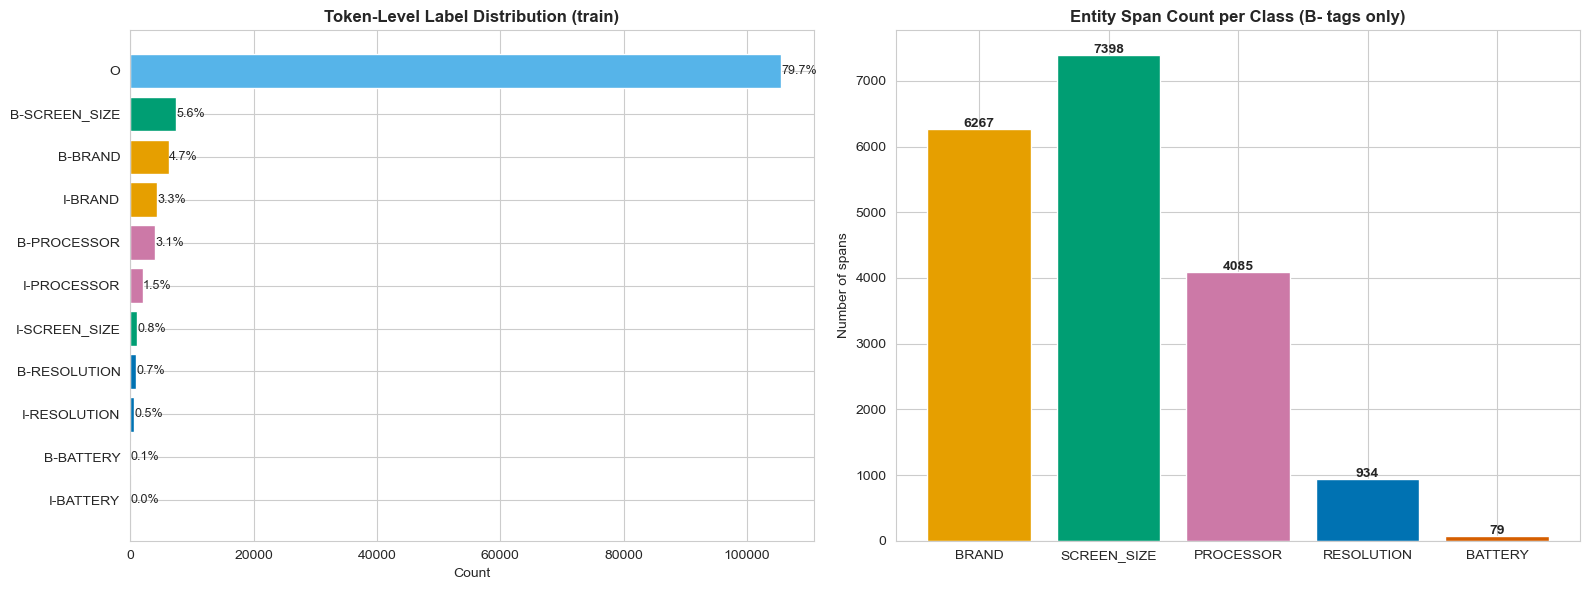

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full label distribution
labels_sorted = sorted(label_counts.items(), key=lambda x: -x[1])
lbls = [l for l, _ in labels_sorted]
cnts = [c for _, c in labels_sorted]
bar_colors = [COLORS[0] if l == 'O' else COLORS[ENTITY_TYPES.index(l.split('-')[1]) % len(COLORS) + 1]
              if '-' in l and l.split('-')[1] in ENTITY_TYPES else COLORS[1] for l in lbls]

axes[0].barh(lbls[::-1], cnts[::-1], color=bar_colors[::-1], edgecolor='white')
axes[0].set_title('Token-Level Label Distribution (train)', fontweight='bold')
axes[0].set_xlabel('Count')
for i, (lbl, cnt) in enumerate(zip(lbls[::-1], cnts[::-1])):
    axes[0].text(cnt + 50, i, f'{cnt/total_tokens:.1%}', va='center', fontsize=9)

# Entity-level (only B- tags)
entity_counts = {e: label_counts.get(f'B-{e}', 0) for e in ENTITY_TYPES}
axes[1].bar(entity_counts.keys(), entity_counts.values(),
            color=COLORS[1:len(ENTITY_TYPES)+1], edgecolor='white')
axes[1].set_title('Entity Span Count per Class (B- tags only)', fontweight='bold')
axes[1].set_ylabel('Number of spans')
for i, (k, v) in enumerate(entity_counts.items()):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The left chart confirms the dominance of `O` tokens at the token level. The right chart counts only `B-` tags, which correspond to the number of distinct entity spans per class. `SCREEN_SIZE` is the most frequent entity (7,398 spans), followed by `BRAND` (6,267) and `PROCESSOR` (4,085). `RESOLUTION` has 934 spans and `BATTERY` only 79 — roughly 94 times fewer than `SCREEN_SIZE`.  
This extreme imbalance between classes will be a recurring theme throughout the modelling experiments and motivates the label cleaning strategy explored in Notebook 02.

## 5) Entity Coverage Analysis

Span count alone does not capture how broadly each entity class is represented across sequences. A class may have many spans but concentrated in few sequences, which limits the variety of contexts the model is exposed to during training. Entity coverage measures the proportion of training sequences that contain at least one span of each class.

Entity coverage (sequences containing at least one entity):
  BRAND           4,567 / 7,479 (61.1%)
  SCREEN_SIZE     6,067 / 7,479 (81.1%)
  PROCESSOR       3,021 / 7,479 (40.4%)
  RESOLUTION      836 / 7,479 (11.2%)
  BATTERY         78 / 7,479 (1.0%)


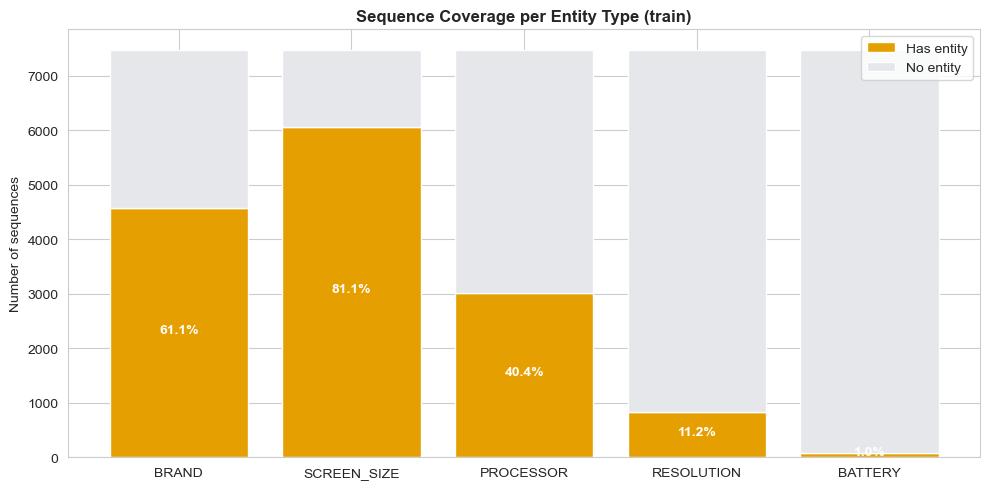

In [9]:
def extract_entities(tokens, labels):
    entities = []
    current_type, current_tokens = None, []
    for tok, lab in zip(tokens, labels):
        if lab.startswith('B-'):
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type = lab[2:]
            current_tokens = [tok]
        elif lab.startswith('I-') and current_type:
            current_tokens.append(tok)
        else:
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type, current_tokens = None, []
    if current_type:
        entities.append((current_type, ' '.join(current_tokens)))
    return entities

# Coverage per entity type
coverage = {}
for etype in ENTITY_TYPES:
    has = sum(1 for r in train_data if any(l.startswith(f'B-{etype}') for l in r['labels']))
    coverage[etype] = has

print('Entity coverage (sequences containing at least one entity):')
for e, cnt in coverage.items():
    print(f'  {e:<15} {cnt:,} / {len(train_data):,} ({cnt/len(train_data):.1%})')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ENTITY_TYPES))
labeled   = [coverage[e] for e in ENTITY_TYPES]
unlabeled = [len(train_data) - coverage[e] for e in ENTITY_TYPES]
ax.bar(x, labeled,   label='Has entity',    color=COLORS[1], edgecolor='white')
ax.bar(x, unlabeled, bottom=labeled,        label='No entity', color='#E5E7EB', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(ENTITY_TYPES)
ax.set_title('Sequence Coverage per Entity Type (train)', fontweight='bold')
ax.set_ylabel('Number of sequences')
ax.legend()
for i, cnt in enumerate(labeled):
    ax.text(i, cnt/2, f'{cnt/len(train_data):.1%}', ha='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('entity_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

`SCREEN_SIZE` appears in 81.1% of training sequences, making it the most consistently present entity. `BRAND` covers 61.1% of sequences and `PROCESSOR` 40.4%. `RESOLUTION` drops sharply to 11.2%, and `BATTERY` is present in only 1.0% of sequences — just 78 out of 7,479. This confirms that the class imbalance observed at token level is not an artifact of span length but reflects a genuine scarcity of annotated examples. A model trained on this distribution will encounter `BATTERY` contexts extremely rarely, which limits its ability to generalise beyond the most obvious lexical triggers.

## 6) Entity Value Distribution

Analysing the most frequent entity values and their span lengths reveals two important properties of the dataset: the degree of lexical diversity within each class, and the presence of systematic annotation inconsistencies that will motivate the label cleaning pipeline.

In [10]:
# Extract all entity spans
entity_values = defaultdict(list)
for r in train_data:
    for etype, val in extract_entities(r['tokens'], r['labels']):
        entity_values[etype].append(val.lower())

print('=== Top 10 entity values per class ===')
for etype in ENTITY_TYPES:
    counter = Counter(entity_values[etype])
    print(f'\n{etype} (total: {len(entity_values[etype]):,}, unique: {len(counter):,})')
    for val, cnt in counter.most_common(10):
        print(f'  {cnt:4d}x  "{val}"')

# Span length distribution (in tokens)
span_lengths = defaultdict(list)
for r in train_data:
    for etype, val in extract_entities(r['tokens'], r['labels']):
        span_lengths[etype].append(len(val.split()))

print('\n=== Span length (tokens) per class ===')
for etype in ENTITY_TYPES:
    lens = span_lengths[etype]
    if lens:
        print(f'  {etype:<15} mean={np.mean(lens):.2f}  max={max(lens)}  multi-token={sum(1 for l in lens if l>1)/len(lens):.1%}')

=== Top 10 entity values per class ===

BRAND (total: 6,267, unique: 1,747)
  1428x  "intel core"
   374x  "(intel core"
   336x  "pentium"
   248x  "intel"
   233x  "celeron"
   143x  "amd"
   110x  "core i5"
   100x  "turion"
    96x  "core 2"
    75x  "atom"

SCREEN_SIZE (total: 7,398, unique: 1,241)
   961x  "15.6""
   896x  "15.6-inch"
   322x  "17.3-inch"
   297x  "14""
   281x  "14-inch"
   249x  "17.3""
   240x  "13.3-inch"
   225x  "15.4""
   200x  "13.3""
   165x  "11.6""

PROCESSOR (total: 4,085, unique: 1,386)
   194x  "quad-core"
   193x  "dual-core"
   112x  "quad core"
   109x  "dual core"
   104x  "(2.0 ghz"
    76x  "2.5ghz"
    72x  "2.4ghz"
    54x  "dual"
    49x  "quad"
    47x  "(1.6 ghz"

RESOLUTION (total: 934, unique: 474)
    67x  "1080p"
    58x  "(1920x1080)"
    48x  "1920x1080"
    23x  "qhd+"
    22x  "1920 x 1080"
    19x  "(1920 x 1080)"
    18x  "1366 x 768"
    15x  "(1366x768),"
    15x  "(1366x768)"
    14x  "3200x1800"

BATTERY (total: 79, unique: 

The `BRAND` class immediately reveals the most critical annotation artifact in the dataset: processor families such as *Intel Core*, *Pentium*, *Celeron*, *AMD*, and *Atom* appear among the top entity values, despite being manufacturer or processor brand names that are inconsistently annotated across sequences — sometimes as `BRAND`, sometimes as `PROCESSOR`, and sometimes as `O`. This ambiguity is the primary source of noise addressed by the label cleaning pipeline in Notebook 02.

`SCREEN_SIZE` shows high surface form variability for the same physical value: *15.6"*, *15.6-inch*, and *15.6 inch* are treated as distinct spans despite being semantically identical. `RESOLUTION` exhibits the same problem at a larger scale: *1920x1080*, *(1920x1080)*, *1920 x 1080*, and *1080p* all refer to Full HD but are never normalised in the original annotations — 474 unique surface forms for only 934 total spans. `BATTERY` spans are almost entirely expressed as duration (*8 hours*, *6 hours*), with very limited lexical variety across only 46 unique values.

Regarding span length, `BATTERY` has the highest proportion of multi-token spans (79.7%), while `SCREEN_SIZE` is predominantly single-token (only 13.6% multi-token). These differences have direct implicatio

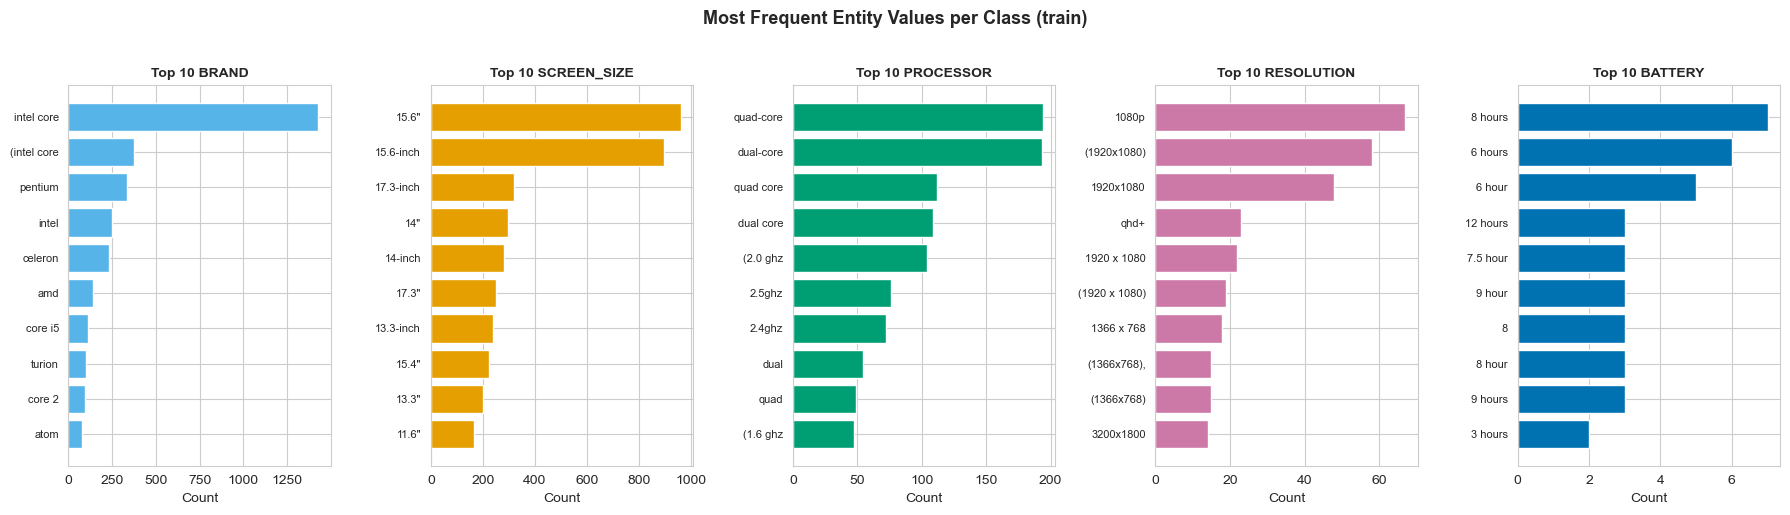

In [11]:
fig, axes = plt.subplots(1, len(ENTITY_TYPES), figsize=(18, 5))
for i, etype in enumerate(ENTITY_TYPES):
    counter = Counter(entity_values[etype])
    top10   = counter.most_common(10)
    vals    = [v for v, _ in top10]
    cnts    = [c for _, c in top10]
    axes[i].barh(vals[::-1], cnts[::-1], color=COLORS[i % len(COLORS)], edgecolor='white')
    axes[i].set_title(f'Top 10 {etype}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].tick_params(axis='y', labelsize=8)
plt.suptitle('Most Frequent Entity Values per Class (train)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('entity_values.png', dpi=150, bbox_inches='tight')
plt.show()

The charts make the annotation inconsistencies immediately visible. In the `BRAND` panel, *Intel Core* dominates by a large margin — appearing nearly four times more than the next entry — despite being a processor family rather than a manufacturer brand. In the `RESOLUTION` panel, the fragmentation of surface forms for the same physical

## 7) Entity Co-occurrence Analysis

In product titles, multiple entity types frequently appear within the same sequence. Analysing which classes tend to co-occur provides insight into the structural patterns of the dataset and helps anticipate challenges for the model — in particular, sequences where the model must simultaneously resolve boundaries for several entity types in close proximity.

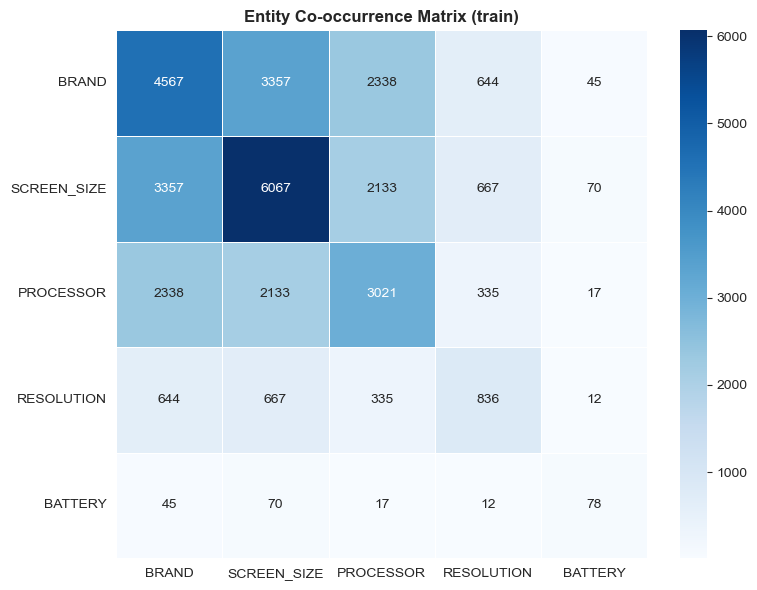

Most common entity combinations:
  2,083x  SCREEN_SIZE
  1,415x  BRAND + PROCESSOR + SCREEN_SIZE
  1,404x  BRAND + SCREEN_SIZE
    654x  BRAND + PROCESSOR
    435x  PROCESSOR + SCREEN_SIZE
    414x  BRAND
    299x  BRAND + RESOLUTION + SCREEN_SIZE
    200x  BRAND + PROCESSOR + RESOLUTION + SCREEN_SIZE
    172x  PROCESSOR
     92x  RESOLUTION + SCREEN_SIZE


In [12]:
# Co-occurrence matrix
cooc = np.zeros((len(ENTITY_TYPES), len(ENTITY_TYPES)), dtype=int)
for r in train_data:
    present = set()
    for l in r['labels']:
        if l.startswith('B-'):
            etype = l[2:]
            if etype in ENTITY_TYPES:
                present.add(etype)
    for e1 in present:
        for e2 in present:
            cooc[ENTITY_TYPES.index(e1)][ENTITY_TYPES.index(e2)] += 1

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues',
            xticklabels=ENTITY_TYPES, yticklabels=ENTITY_TYPES,
            linewidths=0.5, ax=ax)
ax.set_title('Entity Co-occurrence Matrix (train)', fontweight='bold')
plt.tight_layout()
plt.savefig('cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

# Combo labels
def get_combo(labels):
    types = sorted(set(l[2:] for l in labels if l.startswith('B-') and l[2:] in ENTITY_TYPES))
    return ' + '.join(types) if types else 'O only'

combo_counts = Counter(get_combo(r['labels']) for r in train_data)
print('Most common entity combinations:')
for combo, cnt in combo_counts.most_common(10):
    print(f'  {cnt:5,}x  {combo}')

The co-occurrence matrix confirms that `SCREEN_SIZE` is the most self-co-occurring entity (6,067 sequences contain at least one `SCREEN_SIZE` span), and that `BRAND + PROCESSOR + SCREEN_SIZE` is the most frequent multi-entity combination, appearing in 1,415 sequences. This reflects the canonical structure of a laptop product title (e.g. *Lenovo IdeaPad Intel Core i5 15.6-inch*), where brand, processor, and screen size are routinely mentioned together.  

`BATTERY` is almost entirely isolated: it rarely co-occurs with any other class (at most 70 sequences with `SCREEN_SIZE`), consistent with its extreme scarcity in the dataset. `RESOLUTION` co-occurs most often with `SCREEN_SIZE` (667 sequences), which is linguistically expected since display resolution and screen dimensions tend to appear together in product descriptions.  

These patterns have a direct implication for sequence labelling: in sequences containing three or more entity types, the model must simultaneously resolve multiple span boundaries without letting the prediction of one entity interfere with adjacent ones. This is precisely the scenario where a CRF output layer provides a structural advantage — by modelling transition probabilities between labels, it enforces globally consistent tag sequences rather than making independent per-token decisions.

## 8) Lexical Ambiguity Analysis

A key challenge in NER is lexical ambiguity: the same token appearing under different entity labels across training sequences. In a noisy, crowdsourced dataset such as MAVE, this ambiguity can arise both from genuine linguistic context-dependence (e.g. a numeric token like "13" that may refer to a screen size or a processor generation) and from inconsistent annotation practices. Quantifying the extent of this ambiguity is important because it sets an upper bound on what a purely lexical model can achieve — a token that has been labelled differently across sequences cannot be resolved by surface form alone, and requires contextual reasoning.

In [13]:
# Tokens that appear with multiple different labels
token_label_map = defaultdict(set)
for r in train_data:
    for tok, lbl in zip(r['tokens'], r['labels']):
        base = lbl if lbl == 'O' else lbl.split('-')[1]
        token_label_map[tok.lower()].add(base)

ambiguous = {tok: lbls for tok, lbls in token_label_map.items() if len(lbls) > 1}
print(f'Ambiguous tokens (appear with >1 label type): {len(ambiguous):,}')
print('\nTop 20 most ambiguous tokens:')
sorted_amb = sorted(ambiguous.items(), key=lambda x: len(x[1]), reverse=True)[:20]
for tok, lbls in sorted_amb:
    print(f'  "{tok:<20}" → {sorted(lbls)}')

# Vocabulary stats
all_tokens = [t.lower() for r in train_data for t in r['tokens']]
vocab = Counter(all_tokens)
print(f'\nVocabulary size:    {len(vocab):,}')
print(f'Unique tokens:      {len(vocab):,}')
print(f'Hapax legomena:     {sum(1 for c in vocab.values() if c == 1):,} ({sum(1 for c in vocab.values() if c==1)/len(vocab):.1%})')

Ambiguous tokens (appear with >1 label type): 1,495

Top 20 most ambiguous tokens:
  "laptop              " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "inspiron            " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "processor,          " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "-                   " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "ram                 " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "2gb                 " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "ssd                 " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "10                  " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "4gb                 " → ['BATTERY', 'BRAND', 'O', 'PROCESSOR', 'RESOLUTION', 'SCREEN_SIZE']
  "netbook             " → ['BATTERY', 'BRAND', 'O', 'PROCESSO

The analysis identifies 1,495 ambiguous tokens in the training vocabulary — tokens that appear under more than one label type across different sequences. Several of the most ambiguous entries (e.g. `"laptop"`, `"inspiron"`, `"-"`, `"ram"`) are associated with all six possible label values, including `O`. This is partly a genuine annotation challenge, but also reflects tokenisation noise: punctuation attached to words (e.g. `"processor,"`, `"ram,"`) is treated as a distinct token, inflating the ambiguity count artificially.  

More linguistically meaningful are tokens such as `"dell"`, `"thinkpad"`, and `"15.6-inch"`, which appear primarily as `BRAND` or `SCREEN_SIZE` but are occasionally labelled `O` or misassigned. This confirms a pattern of systematic annotation inconsistency rather than genuine contextual ambiguity: the same manufacturer name is sometimes tagged as `BRAND` and sometimes left unlabelled, depending on the annotator.  

The vocabulary statistics further reveal that 68.6% of tokens are hapax legomena — appearing only once in the training set. This high proportion of rare tokens limits the effectiveness of purely frequency-based representations and motivates the use of subword-aware or character-level encodings, such as the Char-CNN component in the BiLSTM model and the WordPiece tokeniser in DeBERTa, both of which can generalise to unseen or low-frequency surface forms.

## 9) Token Frequency per Class

Examining the most frequent tokens within each entity class provides a lexical profile of each category and helps identify potential sources of noise. Tokens that dominate a class vocabulary are strong positive indicators for that label; tokens that appear frequently across multiple classes signal ambiguity and are harder for the model to resolve without contextual information.

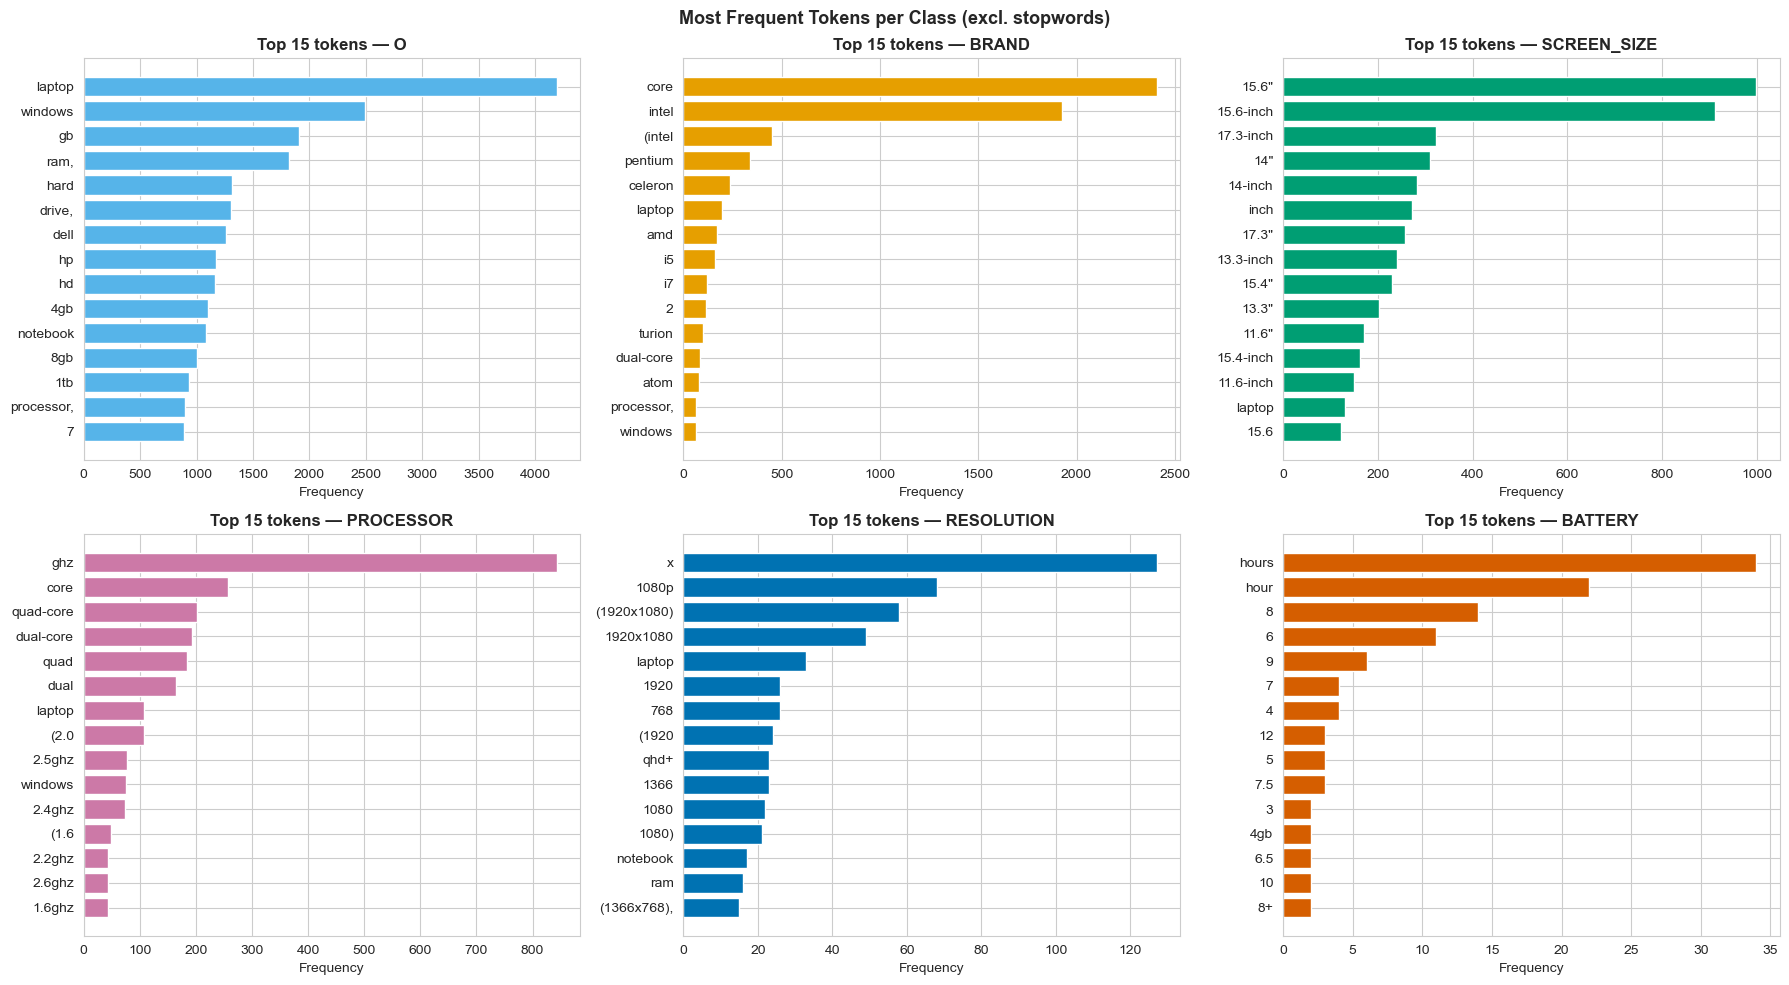

In [14]:
import spacy
import string
nlp = spacy.load('en_core_web_sm')
PUNCT = set(string.punctuation)

# Token frequency per class, excluding stopwords and pure punctuation
class_tokens = defaultdict(list)
for r in train_data:
    for tok, lbl in zip(r['tokens'], r['labels']):
        base = lbl if lbl == 'O' else lbl.split('-')[1]
        tok_lower = tok.lower()
        if tok_lower not in nlp.Defaults.stop_words and not all(c in PUNCT for c in tok_lower):
            class_tokens[base].append(tok_lower)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
all_classes = ['O'] + ENTITY_TYPES

for i, cls in enumerate(all_classes):
    if i >= len(axes_flat):
        break
    counter = Counter(class_tokens[cls])
    top15 = counter.most_common(15)
    if not top15:
        axes_flat[i].set_visible(False)
        continue
    toks = [t for t, _ in top15]
    cnts = [c for _, c in top15]
    axes_flat[i].barh(toks[::-1], cnts[::-1], color=COLORS[i % len(COLORS)], edgecolor='white')
    axes_flat[i].set_title(f'Top 15 tokens — {cls}', fontweight='bold')
    axes_flat[i].set_xlabel('Frequency')

for j in range(len(all_classes), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Most Frequent Tokens per Class (excl. stopwords)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('token_freq_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

The per-class token distributions reveal clear lexical signatures for most entity types. `SCREEN_SIZE` is dominated by surface forms such as `"15.6"`, `"15.6-inch"`, and `"14-inch"`, confirming that this class is largely identifiable by a compact set of recurring patterns. `PROCESSOR` is characterised by frequency and architecture descriptors (`"ghz"`, `"core"`, `"quad-core"`, `"dual-core"`), while `BATTERY` is defined almost entirely by duration expressions (`"hours"`, `"hour"`, followed by numeric values).  

`BRAND`, however, shows a more problematic distribution: `"core"` and `"intel"` rank as the top two tokens, well above actual manufacturer names such as `"amd"` or `"pentium"`. This directly reflects the annotation inconsistency identified earlier — Intel processor descriptors have been systematically labelled as `BRAND` in a large proportion of sequences, conflating two semantically distinct entity types.  

`RESOLUTION` exhibits high surface variability: the same resolution value appears in multiple formats (`"1080p"`, `"1920x1080"`, `"(1920x1080)"`, `"1920"`, `"1080"`), sometimes as a single token and sometimes split across several. This fragmentation, caused by inconsistent punctuation handling in the original dataset, makes `RESOLUTION` particularly difficult to learn — the model must recognise the same semantic value expressed in structurally different ways.  

Several tokens appear with trailing punctuation (`"ram,"`, `"processor,"`, `"(intel"`), which are treated as distinct vocabulary items. This is a direct consequence of the dataset's tokenisation strategy, which does not systematically separate punctuation from adjacent words.  

## 10) Annotation Noise Quantification

The qualitative ambiguity observed in previous sections can be quantified more precisely by measuring two related phenomena: entity value overlap across classes (the same surface string labelled as different entity types in different sequences) and token-level B- label conflicts (the same token used as the beginning of spans belonging to different classes). Together, these metrics provide a concrete estimate of the annotation inconsistency that acts as a structural ceiling on model performance.

In [22]:
# Surface-level: entity value overlap across classes
entity_by_class = defaultdict(set)
for r in train_data:
    for etype, val in extract_entities(r['tokens'], r['labels']):
        entity_by_class[etype].add(val.lower())

print('Entity value overlap across classes (surface-level noise indicator):')
for i, e1 in enumerate(ENTITY_TYPES):
    for e2 in ENTITY_TYPES[i+1:]:
        overlap = entity_by_class[e1] & entity_by_class[e2]
        if overlap:
            print(f'  {e1} ∩ {e2}: {len(overlap)} overlapping values')
            for v in list(overlap)[:5]:
                print(f'    "{v}"')

# Token appearing with conflicting B- labels
token_b_labels = defaultdict(set)
for r in train_data:
    for tok, lbl in zip(r['tokens'], r['labels']):
        if lbl.startswith('B-'):
            token_b_labels[tok.lower()].add(lbl)

conflicting = {tok: lbls for tok, lbls in token_b_labels.items() if len(lbls) > 1}
print(f'\nTokens with conflicting B- labels: {len(conflicting)}')
for tok, lbls in list(conflicting.items())[:10]:
    print(f'  "{tok}" → {sorted(lbls)}')

Entity value overlap across classes (surface-level noise indicator):
  BRAND ∩ SCREEN_SIZE: 219 overlapping values
    "15.6 inch"
    "dvd±rw"
    "by manufacturer]"
    "core i7"
    "apple macbook"
  BRAND ∩ PROCESSOR: 230 overlapping values
    "2.5ghz,"
    "13.3-inch laptop"
    "core i7"
    "2.2ghz,"
    "apple macbook"
  BRAND ∩ RESOLUTION: 72 overlapping values
    "processor"
    "pentium"
    "i5-4300u"
    "webcam"
    "dell latitude"
  BRAND ∩ BATTERY: 6 overlapping values
    "processor"
    "processor,"
    "netbook"
    "10"
    "inspiron"
  SCREEN_SIZE ∩ PROCESSOR: 188 overlapping values
    "core i7"
    "mobile workstation"
    "2.10 ghz"
    "(black)"
    "lenovo"
  SCREEN_SIZE ∩ RESOLUTION: 54 overlapping values
    "processor"
    "pentium"
    "i5-4300u"
    "webcam"
    "15.5-inch"
  SCREEN_SIZE ∩ BATTERY: 6 overlapping values
    "processor"
    "processor,"
    "netbook"
    "10"
    "4gb ram,"
  PROCESSOR ∩ RESOLUTION: 56 overlapping values
    "processor"
 

The overlap analysis reveals that `BRAND` is the most affected class: 230 of its entity values also appear as `PROCESSOR` spans, and 219 overlap with `SCREEN_SIZE`. Inspection of the overlapping values confirms that this is not genuine ambiguity but systematic mislabelling — strings such as `"core i7"`, `"2.5ghz,"`, and `"apple macbook"` are processor or product descriptors that have been inconsistently assigned to `BRAND` across different sequences.  

At the token level, 426 tokens appear with conflicting `B-` labels. The most telling cases are `"intel"`, `"core"`, and `"dual-core"`, which are tagged as `B-BRAND`, `B-PROCESSOR`, `B-RESOLUTION`, and `B-SCREEN_SIZE` across different sequences. Since these tokens are unambiguous from a semantic standpoint — they clearly refer to processor architecture — their label instability is direct evidence of annotation noise rather than genuine linguistic context-dependence.  

This quantification motivates the label cleaning pipeline developed in Notebook 04: a rule-first strategy targeting the most frequent and unambiguous conflict patterns, with an LLM fallback for genuinely ambiguous cases. It also sets a realistic expectation for model performance — any model trained on this data will partially learn the noise, and its test score will reflect consistency with the annotation artefacts as much as true entity recognition ability.  

### 10.2) BRAND Annotation Ambiguity

One of the most significant sources of noise in the dataset concerns the `BRAND` class. In a product title such as *"Lenovo ThinkPad T450 Intel Core i5 1920x1080"*, two distinct brand entities are present: the laptop manufacturer (`Lenovo`) and the processor manufacturer (`Intel`). The MAVE annotations do not follow a consistent convention for this case — in some sequences only the laptop brand is tagged, in others only the processor brand, and in others both.  

This inconsistency creates a natural performance ceiling for all models: regardless of architecture, a model trained on these labels learns an ambiguous signal and cannot distinguish the two brand types without a consistent supervisory signal. The analysis below quantifies this problem along three dimensions: the frequency of multi-brand sequences, the tokens that alternate between `BRAND` and `O` across sequences, and the overall extent of annotation inconsistency for this class.

=== BRAND entity count per sequence ===
  No BRAND:    2,912 sequences (38.9%)
  1 BRAND:     3,068 sequences (41.0%)
  2+ BRANDs:   1,499 sequences (20.0%)

--- Examples of sequences with 2+ BRAND entities ---
  Tokens: Asus Premium 15.6" Inch Laptop PC Latest Intel 5th Gen Core i3-5020U 2.2GHz 12GB RAM DDR3L Memory 180GB Solid State Drive SSD SuperMulti DVD USB 3.0 HDMI SD Card Reader Webcam WiFi Ethernet Windows 10
  BRANDs: ['Intel', 'Core i3-5020U']

  Tokens: Acer C720-2103 Chromebook (11.6-Inch, Intel Celeron, 2GB DDR3L, 16GB SSD)
  BRANDs: ['Celeron,', '16GB SSD)']

  Tokens: Sony VAIO VGN-N250N/B 15.4" Laptop (Intel Core Duo Processor T2250, 1 GB RAM, 120 GB Hard Drive, DVDRW Drive, Vista Business)
  BRANDs: ['(Intel', 'GB RAM, 120']

  Tokens: Alienware M17 AM17xR4-7895BK 17.3-Inch Laptop (2.4 GHz Intel Core i7-3630QM Processor, 8GB DDR3, 500GB HDD, Windows 8) Stealth Black [Discontinued By Manufacturer]
  BRANDs: ['GHz', 'Intel Core']

  Tokens: GATEWAY Gateway NV5453U Noteb

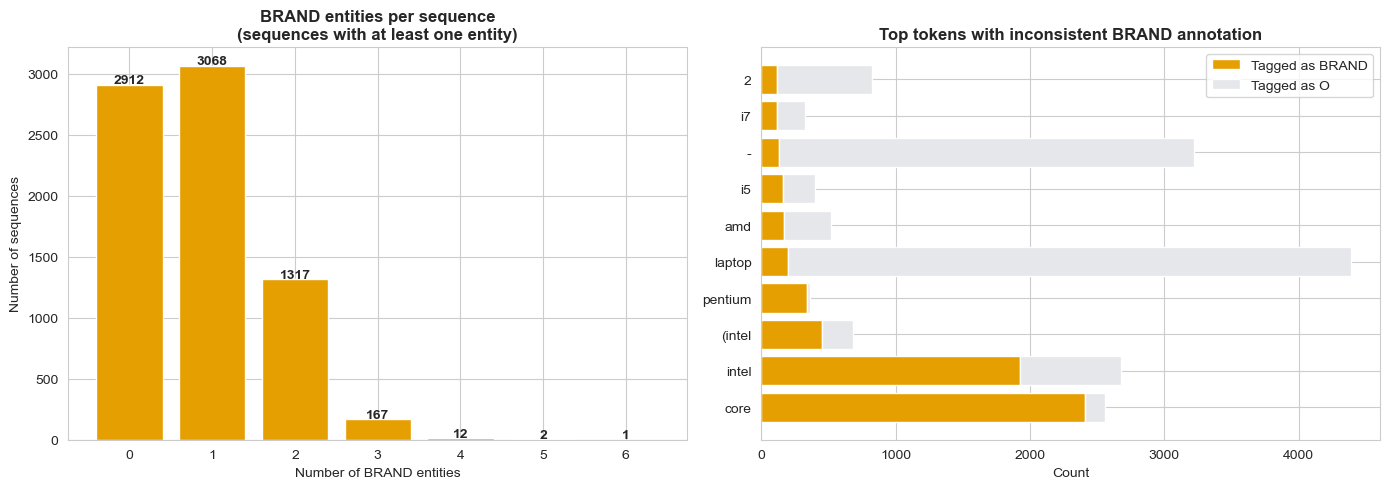


→ Conclusion: BRAND annotation inconsistency is a dataset-level issue.
  The model cannot resolve ambiguity that is not resolved in the training labels.
  Expected impact: BRAND F1 ceiling regardless of model architecture.


In [23]:
# ── BRAND Annotation Ambiguity Analysis ──

# 1. Frasi con più di un'entità BRAND
multi_brand_seqs = [r for r in train_data if r['labels'].count('B-BRAND') > 1]
single_brand_seqs = [r for r in train_data if r['labels'].count('B-BRAND') == 1]
no_brand_seqs = [r for r in train_data if r['labels'].count('B-BRAND') == 0]

print('=== BRAND entity count per sequence ===')
print(f'  No BRAND:    {len(no_brand_seqs):,} sequences ({len(no_brand_seqs)/len(train_data):.1%})')
print(f'  1 BRAND:     {len(single_brand_seqs):,} sequences ({len(single_brand_seqs)/len(train_data):.1%})')
print(f'  2+ BRANDs:   {len(multi_brand_seqs):,} sequences ({len(multi_brand_seqs)/len(train_data):.1%})')

# Show examples of multi-brand sequences
print(f'\n--- Examples of sequences with 2+ BRAND entities ---')
for r in multi_brand_seqs[:5]:
    entities = extract_entities(r['tokens'], r['labels'])
    brands = [val for etype, val in entities if etype == 'BRAND']
    print(f'  Tokens: {" ".join(r["tokens"])}')
    print(f'  BRANDs: {brands}')
    print()

# 2. Tokens that appear as BRAND in some sequences and O in others
token_brand_map = defaultdict(lambda: {'BRAND': 0, 'O': 0})
for r in train_data:
    for tok, lbl in zip(r['tokens'], r['labels']):
        t = tok.lower()
        if 'BRAND' in lbl:
            token_brand_map[t]['BRAND'] += 1
        elif lbl == 'O':
            token_brand_map[t]['O'] += 1

# Tokens that appear as both BRAND and O — annotation inconsistency
inconsistent_brands = {
    tok: counts for tok, counts in token_brand_map.items()
    if counts['BRAND'] > 5 and counts['O'] > 5
}
inconsistent_sorted = sorted(inconsistent_brands.items(),
                              key=lambda x: x[1]['BRAND'], reverse=True)[:15]

print('=== Top tokens appearing as both BRAND and O (annotation inconsistency) ===')
print(f'  {"Token":<20} {"as BRAND":>10} {"as O":>10} {"BRAND ratio":>12}')
print('  ' + '-'*55)
for tok, counts in inconsistent_sorted:
    total = counts['BRAND'] + counts['O']
    ratio = counts['BRAND'] / total
    print(f'  {tok:<20} {counts["BRAND"]:>10} {counts["O"]:>10} {ratio:>11.1%}')

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: BRAND count distribution per sequence
brand_counts_per_seq = [r['labels'].count('B-BRAND') for r in train_data
                        if any(l.startswith('B-') for l in r['labels'])]
from collections import Counter as C
bc = C(brand_counts_per_seq)
axes[0].bar(bc.keys(), bc.values(), color=COLORS[1], edgecolor='white')
axes[0].set_title('BRAND entities per sequence\n(sequences with at least one entity)', fontweight='bold')
axes[0].set_xlabel('Number of BRAND entities')
axes[0].set_ylabel('Number of sequences')
for k, v in bc.items():
    axes[0].text(k, v + 10, str(v), ha='center', fontweight='bold')

# Right: top inconsistent brand tokens
top_tokens = [tok for tok, _ in inconsistent_sorted[:10]]
brand_counts_vals = [inconsistent_brands[t]['BRAND'] for t in top_tokens]
o_counts_vals = [inconsistent_brands[t]['O'] for t in top_tokens]
x = np.arange(len(top_tokens))
axes[1].barh(x, brand_counts_vals, label='Tagged as BRAND', color=COLORS[1], edgecolor='white')
axes[1].barh(x, o_counts_vals, left=brand_counts_vals, label='Tagged as O', color='#E5E7EB', edgecolor='white')
axes[1].set_yticks(x)
axes[1].set_yticklabels(top_tokens)
axes[1].set_title('Top tokens with inconsistent BRAND annotation', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].legend()
plt.tight_layout()
plt.savefig('brand_ambiguity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Conclusion: BRAND annotation inconsistency is a dataset-level issue.')
print('  The model cannot resolve ambiguity that is not resolved in the training labels.')
print('  Expected impact: BRAND F1 ceiling regardless of model architecture.')

The data confirms that 20% of sequences containing at least one entity have two or more `BRAND` spans — a direct consequence of the dual-brand pattern described above. The examples make this explicit: processor descriptors such as `"Intel Core i3-5020U"`, `"Celeron"`, and `"GHz"` are tagged as `BRAND` in sequences where the laptop manufacturer is also present, reflecting inconsistent annotator decisions rather than genuine semantic ambiguity.  

The inconsistency table further shows that `"core"` is tagged as `BRAND` in 93.9% of its occurrences, and `"intel"` in 71.9% — confirming that Intel processor architecture tokens have been systematically absorbed into the `BRAND` class. Conversely, tokens such as `"amd"`, `"i5"`, and `"i7"` show much lower and more variable BRAND ratios, indicating that the annotation convention was applied unevenly even within the processor manufacturer category.  

This analysis directly motivates the rule-based corrections applied in the cleaning pipeline of Notebook 04, where Intel processor tokens are reassigned from `BRAND` to `PROCESSOR` as the highest-priority correction rule.

### 10.3) RESOLUTION Lexical Variability

Among all entity classes, `RESOLUTION` exhibits the highest surface form variability. The same resolution value can be expressed in fundamentally different ways — `"1920x1080"`, `"1080p"`, `"(1920x1080)"`, `"1920 x 1080"`, and `"Full HD"` all refer to the same physical resolution, yet each constitutes a distinct token sequence from the model's perspective. This fragmentation limits generalisation: a model that has learned to recognise `"1080p"` has no guarantee of correctly tagging `"(1920x1080)"` unless both forms are sufficiently represented in training. A normalisation step applied before tokenisation — mapping all surface variants to a canonical numeric form — is a standard technique for reducing this kind of lexical sparsity in technical NER (Ratinov & Roth, 2009).

=== RESOLUTION surface forms ===
  Total spans:  934
  Unique forms: 474

  Top 30 most frequent RESOLUTION values:
      67x  "1080p"
      58x  "(1920x1080)"
      48x  "1920x1080"
      23x  "qhd+"
      22x  "1920 x 1080"
      19x  "(1920 x 1080)"
      18x  "1366 x 768"
      15x  "(1366x768),"
      15x  "(1366x768)"
      14x  "3200x1800"
      11x  "1080p),"
      11x  "(1920x1080),"
       9x  "(1366 x 768)"
       9x  "1366x768"
       9x  "(1600x900)"
       8x  "(3840x2160)"
       7x  "1600 x 900"
       7x  "(1600 x 900),"
       6x  "xga"
       6x  "laptop"
       5x  "laptop notebook"
       5x  "(2560x1440)"
       5x  "1280 x 800"
       5x  "(2560 x 1440)"
       4x  "3840x2160"
       4x  "(1600 x 900)"
       4x  "premium)"
       4x  "notebook"
       4x  "1600x900"
       4x  "(1920 x 1080),"

=== Canonical resolution grouping ===
  1920x1080: 137 total spans
      67x  "1080p"
      48x  "1920x1080"
      22x  "1920 x 1080"
  1366x768: 27 total spans
      18x

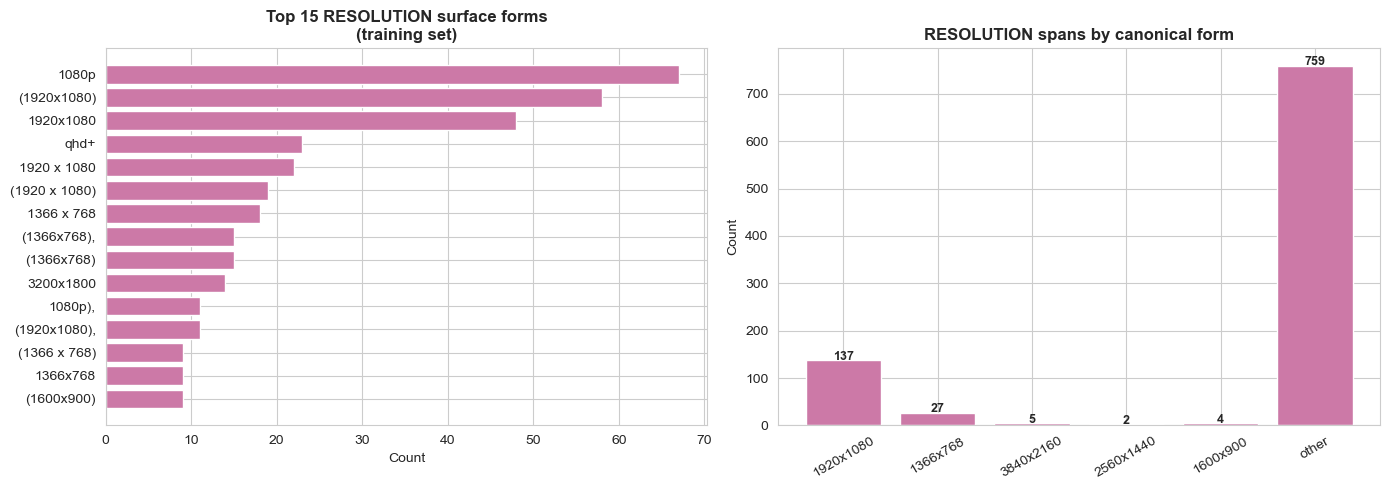


→ Conclusion: RESOLUTION has the highest lexical variability of all entity classes.
  A normalization gazetteer applied in preprocessing could improve RESOLUTION F1.
  Current model must learn each surface form independently — limiting generalization.


In [24]:
# ── RESOLUTION Lexical Variability Analysis ──

# All unique RESOLUTION values in training set
resolution_values = Counter(entity_values['RESOLUTION'])

print(f'=== RESOLUTION surface forms ===')
print(f'  Total spans:  {sum(resolution_values.values()):,}')
print(f'  Unique forms: {len(resolution_values):,}')
print()
print('  Top 30 most frequent RESOLUTION values:')
for val, cnt in resolution_values.most_common(30):
    print(f'    {cnt:4d}x  "{val}"')

# Group by canonical resolution
canonical_map = {
    '1920x1080': ['1920x1080', 'fhd', 'full hd', '1080p', '1920 x 1080', 'fullhd'],
    '1366x768':  ['1366x768', 'hd', '1366 x 768', 'hd display'],
    '3840x2160': ['3840x2160', '4k', 'uhd', '4k uhd', '4k ultra hd', 'ultra hd'],
    '2560x1440': ['2560x1440', 'qhd', '2k', 'wqhd'],
    '1600x900':  ['1600x900', 'hd+'],
}

print('\n=== Canonical resolution grouping ===')
for canonical, variants in canonical_map.items():
    total = sum(resolution_values.get(v, 0) for v in variants)
    found = [(v, resolution_values[v]) for v in variants if v in resolution_values]
    if found:
        print(f'  {canonical}: {total} total spans')
        for v, cnt in sorted(found, key=lambda x: -x[1]):
            print(f'    {cnt:4d}x  "{v}"')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: top 15 resolution values
top15 = resolution_values.most_common(15)
vals = [v for v, _ in top15]
cnts = [c for _, c in top15]
axes[0].barh(vals[::-1], cnts[::-1], color=COLORS[3], edgecolor='white')
axes[0].set_title('Top 15 RESOLUTION surface forms\n(training set)', fontweight='bold')
axes[0].set_xlabel('Count')

# Right: canonical grouping
canonical_totals = {}
for canonical, variants in canonical_map.items():
    canonical_totals[canonical] = sum(resolution_values.get(v, 0) for v in variants)
other = sum(c for v, c in resolution_values.items()
            if not any(v in variants for variants in canonical_map.values()))
canonical_totals['other'] = other

axes[1].bar(canonical_totals.keys(), canonical_totals.values(),
            color=COLORS[3], edgecolor='white')
axes[1].set_title('RESOLUTION spans by canonical form', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(canonical_totals.items()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('resolution_variability.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Conclusion: RESOLUTION has the highest lexical variability of all entity classes.')
print('  A normalization gazetteer applied in preprocessing could improve RESOLUTION F1.')
print('  Current model must learn each surface form independently — limiting generalization.')

The dataset contains 934 `RESOLUTION` spans expressed across 474 distinct surface forms — a type-to-token ratio that confirms extreme lexical fragmentation. The most frequent form, `"1080p"`, appears only 67 times, and even the three most common variants of the same underlying resolution (`"1080p"`, `"(1920x1080)"`, `"1920x1080"`) are treated as separate vocabulary items by the model.  

The canonical grouping makes the extent of the problem concrete: only 175 out of 934 spans (18.7%) can be mapped to one of the five most common canonical resolutions using a small hand-crafted gazetteer. The remaining 759 spans fall into the "other" category, covering a long tail of formats that differ in spacing, parentheses, punctuation, and abbreviation conventions. This directly explains why `RESOLUTION` consistently achieves the lowest F1 score across all model configurations.  

These findings motivated the normalisation preprocessing step tested in Notebook 03, where surface variants are mapped to canonical numeric forms before tokenisation. The ablation results confirm a modest but consistent improvement in `RESOLUTION` F1, validating the hypothesis that lexical sparsity is a primary driver of the class's difficulty.

### 10.4) BATTERY Data Scarcity

The `BATTERY` class presents a different kind of challenge from `BRAND` and `RESOLUTION`: not annotation noise or lexical variability, but extreme data scarcity. With very few training examples available, the model has limited opportunity to learn reliable patterns for this class. Furthermore, evaluation metrics computed on small test sets are statistically unstable — a single misclassified span can shift F1 by 0.10 or more. The NER literature generally treats classes with fewer than 30 spans in the test set as unreliable for F1 estimation (Manning et al., 2014).

train :  79 spans | 143 tokens |  78 sequences (1.0% of train)
val   :   9 spans |  18 tokens |   9 sequences (1.0% of val)
test  :  10 spans |  18 tokens |   9 sequences (1.0% of test)

=== Span count per class per split ===
  Class              Train      Val     Test
  ------------------------------------------
  BRAND              6,267      766      763
  SCREEN_SIZE        7,398      899      932
  PROCESSOR          4,085      530      474
  RESOLUTION           934      128      118
  BATTERY               79        9       10 ⚠️  low support

=== BATTERY unique surface forms: 46 ===
    7x  "8 hours"
    6x  "6 hours"
    5x  "6 hour"
    3x  "12 hours"
    3x  "7.5 hour"
    3x  "9 hour"
    3x  "8"
    3x  "8 hour"
    3x  "9 hours"
    2x  "3 hours"
    2x  "4 hour"
    2x  "10"
    2x  "8+ hours"
    2x  "7"
    2x  "4 hours"
    1x  "8 hour)"
    1x  "(pearl white)"
    1x  "7 hour"
    1x  "5.50 hour"
    1x  "11 hours"


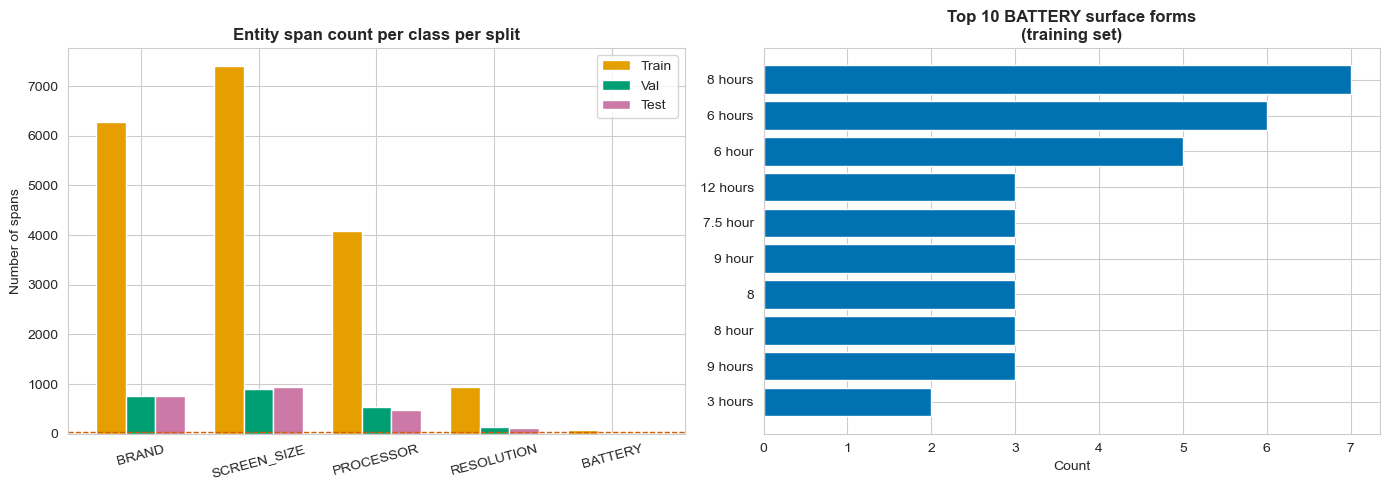


→ Conclusion: BATTERY has critically low support (10 spans in test set).
  F1 metrics for BATTERY are statistically unreliable (high variance).
  Per-class BATTERY results should be interpreted with caution.


In [25]:
# ── BATTERY Data Scarcity Analysis ──

# BATTERY support across splits
for split_name, split_data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    b_spans  = sum(r['labels'].count('B-BATTERY') for r in split_data)
    b_tokens = sum(1 for r in split_data for l in r['labels'] if 'BATTERY' in l)
    b_seqs   = sum(1 for r in split_data if any('BATTERY' in l for l in r['labels']))
    print(f'{split_name:6s}: {b_spans:3d} spans | {b_tokens:3d} tokens | '
          f'{b_seqs:3d} sequences ({b_seqs/len(split_data):.1%} of {split_name})')

print()

# Compare BATTERY support vs other classes
print('=== Span count per class per split ===')
print(f'  {"Class":<15} {"Train":>8} {"Val":>8} {"Test":>8}')
print('  ' + '-'*42)
for etype in ENTITY_TYPES:
    tr = sum(r['labels'].count(f'B-{etype}') for r in train_data)
    va = sum(r['labels'].count(f'B-{etype}') for r in val_data)
    te = sum(r['labels'].count(f'B-{etype}') for r in test_data)
    flag = ' ⚠️  low support' if te < 30 else ''
    print(f'  {etype:<15} {tr:>8,} {va:>8,} {te:>8,}{flag}')

# BATTERY surface forms
battery_values = Counter(entity_values['BATTERY'])
print(f'\n=== BATTERY unique surface forms: {len(battery_values)} ===')
for val, cnt in battery_values.most_common(20):
    print(f'  {cnt:3d}x  "{val}"')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: support comparison across classes and splits
x = np.arange(len(ENTITY_TYPES))
width = 0.25
tr_counts = [sum(r['labels'].count(f'B-{e}') for r in train_data) for e in ENTITY_TYPES]
va_counts = [sum(r['labels'].count(f'B-{e}') for r in val_data)   for e in ENTITY_TYPES]
te_counts = [sum(r['labels'].count(f'B-{e}') for r in test_data)  for e in ENTITY_TYPES]

axes[0].bar(x - width, tr_counts, width, label='Train', color=COLORS[1], edgecolor='white')
axes[0].bar(x,         va_counts, width, label='Val',   color=COLORS[2], edgecolor='white')
axes[0].bar(x + width, te_counts, width, label='Test',  color=COLORS[3], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ENTITY_TYPES, rotation=15)
axes[0].set_title('Entity span count per class per split', fontweight='bold')
axes[0].set_ylabel('Number of spans')
axes[0].legend()
axes[0].axhline(30, color='#D55E00', linestyle='--', linewidth=1, label='min reliable support')

# Right: BATTERY top surface forms
top_bat = battery_values.most_common(10)
axes[1].barh([v for v, _ in top_bat][::-1],
             [c for _, c in top_bat][::-1],
             color=COLORS[4], edgecolor='white')
axes[1].set_title('Top 10 BATTERY surface forms\n(training set)', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('battery_scarcity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Conclusion: BATTERY has critically low support (10 spans in test set).')
print('  F1 metrics for BATTERY are statistically unreliable (high variance).')
print('  Per-class BATTERY results should be interpreted with caution.')

`BATTERY` has only 79 spans in the training set — roughly 1% of all sequences — and just 10 spans in the test set, well below the 30-span reliability threshold. This means that all per-class `BATTERY` F1 scores reported in this project should be interpreted with caution: they reflect performance on a handful of examples and are sensitive to individual annotation decisions.

The surface form analysis adds a further complication: the 79 training spans are spread across 46 distinct forms, including near-duplicates such as `"8 hours"`, `"8 hour"`, and `"8"`. The effective support per form is therefore often just 1–3 examples, making it difficult for the model to generalise even within this already scarce class.

Despite these limitations, `BATTERY` consistently achieves relatively high F1 scores across all model configurations (0.82–0.89). This is likely due to the strong lexical signal of duration expressions (`"hours"`, `"hour"`) which are rarely used in other contexts, making the class recognisable even from limited training data. The instability, however, manifests during training: `BATTERY` validation F1 fluctuates substantially across epochs, not because the model is learning or forgetting, but because a single span prediction changes the metric significantly on a 9-span validation set.

## 11) Class Imbalance Summary & Task Complexity

Before selecting a modelling approach, it is useful to consolidate the quantitative indicators identified throughout the EDA into a single summary. Class imbalance, span complexity, and vocabulary statistics together define the difficulty profile of the task and inform specific architectural and training choices.

In [29]:
print('=== CLASS IMBALANCE SUMMARY ===')
all_labels = [l for r in train_data for l in r['labels']]
label_counts = Counter(all_labels)
total = len(all_labels)

o_ratio     = label_counts['O'] / total
entity_ratio = 1 - o_ratio

print(f'  O tokens:      {o_ratio:.1%} — substantial imbalance typical of real-world NER')
print(f'  Entity tokens: {entity_ratio:.1%}')
print()

# Rarest class
b_counts = {e: label_counts.get(f'B-{e}', 0) for e in ENTITY_TYPES}
rarest   = min(b_counts, key=b_counts.get)
print(f'  Rarest class: {rarest} ({b_counts[rarest]:,} spans) — may require class weighting')

print()
print('=== TASK COMPLEXITY INDICATORS ===')
multi_token = sum(1 for r in train_data for _, val in extract_entities(r['tokens'], r['labels']) if len(val.split()) > 1)
total_spans = sum(len(extract_entities(r['tokens'], r['labels'])) for r in train_data)
print(f'  Multi-token spans: {multi_token:,} / {total_spans:,} ({multi_token/max(total_spans,1):.1%})')
print(f'  Ambiguous tokens:  {len(ambiguous):,}')
print(f'  Vocabulary size:   {len(vocab):,}')
print(f'  Avg seq length:    {np.mean(train_lens):.1f} tokens')

print()
print('=== SPLIT SUMMARY ===')
print(f'  Train: {len(train_data):,} ({len(train_data)/(len(train_data)+len(val_data)+len(test_data)):.0%})')
print(f'  Val:   {len(val_data):,} ({len(val_data)/(len(train_data)+len(val_data)+len(test_data)):.0%})')
print(f'  Test:  {len(test_data):,} ({len(test_data)/(len(train_data)+len(val_data)+len(test_data)):.0%})')

=== CLASS IMBALANCE SUMMARY ===
  O tokens:      79.7% — substantial imbalance typical of real-world NER
  Entity tokens: 20.3%

  Rarest class: BATTERY (79 spans) — may require class weighting

=== TASK COMPLEXITY INDICATORS ===
  Multi-token spans: 7,294 / 18,763 (38.9%)
  Ambiguous tokens:  1,495
  Vocabulary size:   11,440
  Avg seq length:    17.7 tokens

=== SPLIT SUMMARY ===
  Train: 7,479 (80%)
  Val:   935 (10%)
  Test:  935 (10%)


## 12) Model Selection Rationale and Project Pipeline

The EDA has identified three principal sources of difficulty in this dataset: systematic annotation noise (particularly in the `BRAND` class), high lexical variability (`RESOLUTION`), and data scarcity (`BATTERY`). The modelling strategy is designed to address these challenges progressively across four notebooks.

**Notebook 02 — Label Cleaning** applies a rule-first pipeline with LLM fallback to correct the most systematic annotation errors identified in the EDA, in particular the conflation of processor descriptors with the `BRAND` class. Producing a cleaned version of the dataset allows the effect of label quality to be isolated in a controlled experiment where all other variables are held constant.

**Notebook 03 — BiLSTM + CRF** serves as the sequence labelling baseline, trained and evaluated on both the original and cleaned labels. The bidirectional LSTM captures left and right context for each token, and the CRF output layer enforces globally consistent BIO sequences by penalising invalid transitions (e.g. `I-BRAND` following `O`). Its main limitation is reliance on static GloVe embeddings, which assign the same representation to a token regardless of context — a known weakness for ambiguous tokens such as `"intel"` or `"core"`.

**Notebook 04 — DeBERTa-v3-base** is the main transformer model, also trained on both dataset versions. Its disentangled attention mechanism encodes token content and relative position separately, which is particularly suited to technical entities where positional relationships carry semantic information. WordPiece subword tokenisation handles low-frequency technical tokens, and pre-training on large corpora provides implicit knowledge about manufacturer names and processor families that the BiLSTM cannot exploit.

Comparing the two models across both dataset versions produces four experimental conditions that together answer two distinct questions: how much does architecture matter, and how much does label quality matter?

---

### References

- Yang, L. et al. (2022). *MAVE: A Product Dataset for Multi-source Attribute Value Extraction*. WSDM '22.
- Ni, J. et al. (2019). *Justifying Recommendations using Distantly-Labeled Reviews and Fine-grained Aspects*. EMNLP 2019.
- He, P. et al. (2021). *DeBERTa: Decoding-enhanced BERT with Disentangled Attention*. ICLR 2021.
- Lample, G. et al. (2016). *Neural Architectures for Named Entity Recognition*. NAACL 2016.
- Ratinov, L. & Roth, D. (2009). *Design Challenges and Misconceptions in Named Entity Recognition*. CoNLL 2009.
- Manning, C. et al. (2014). *The Stanford CoreNLP Natural Language Processing Toolkit*. ACL 2014.